In [ ]:
from pathlib import Path

In [ ]:
IN_DIR = Path("/mnt/ssd-2/soar-nla/kaylee")


Saved plots to /mnt/ssd-2/soar-nla/kaylee/fv_sweep_plots/


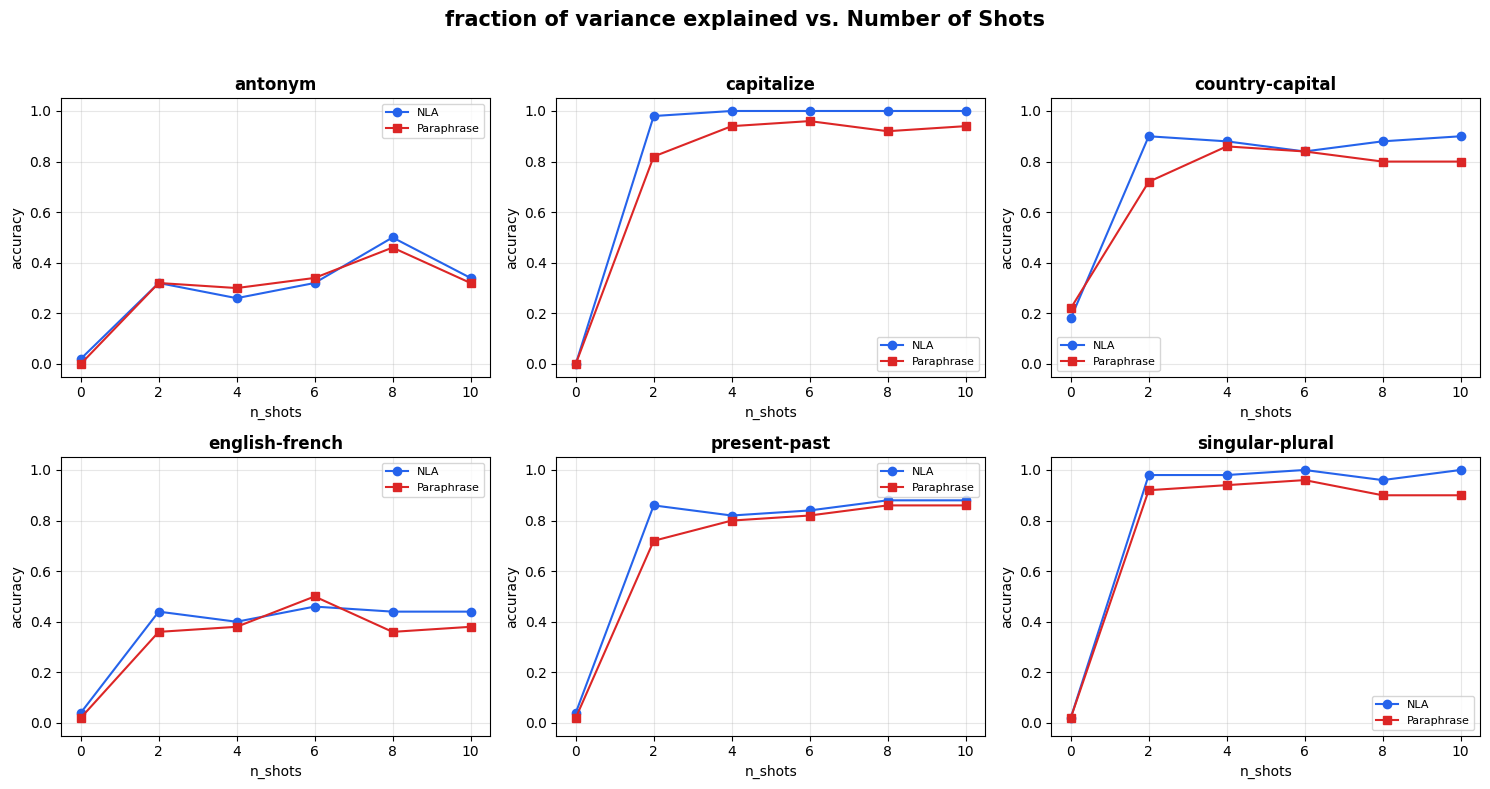

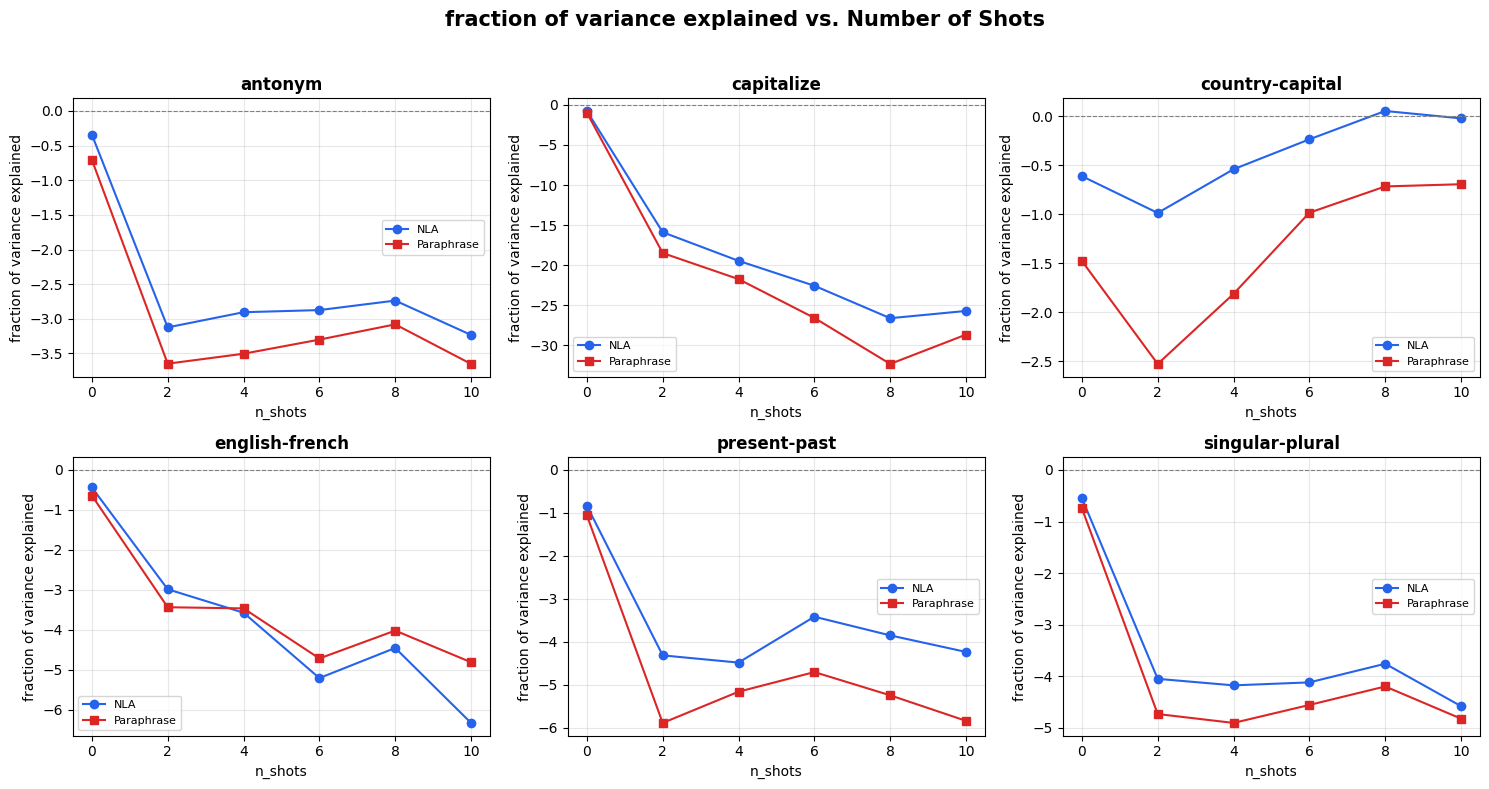

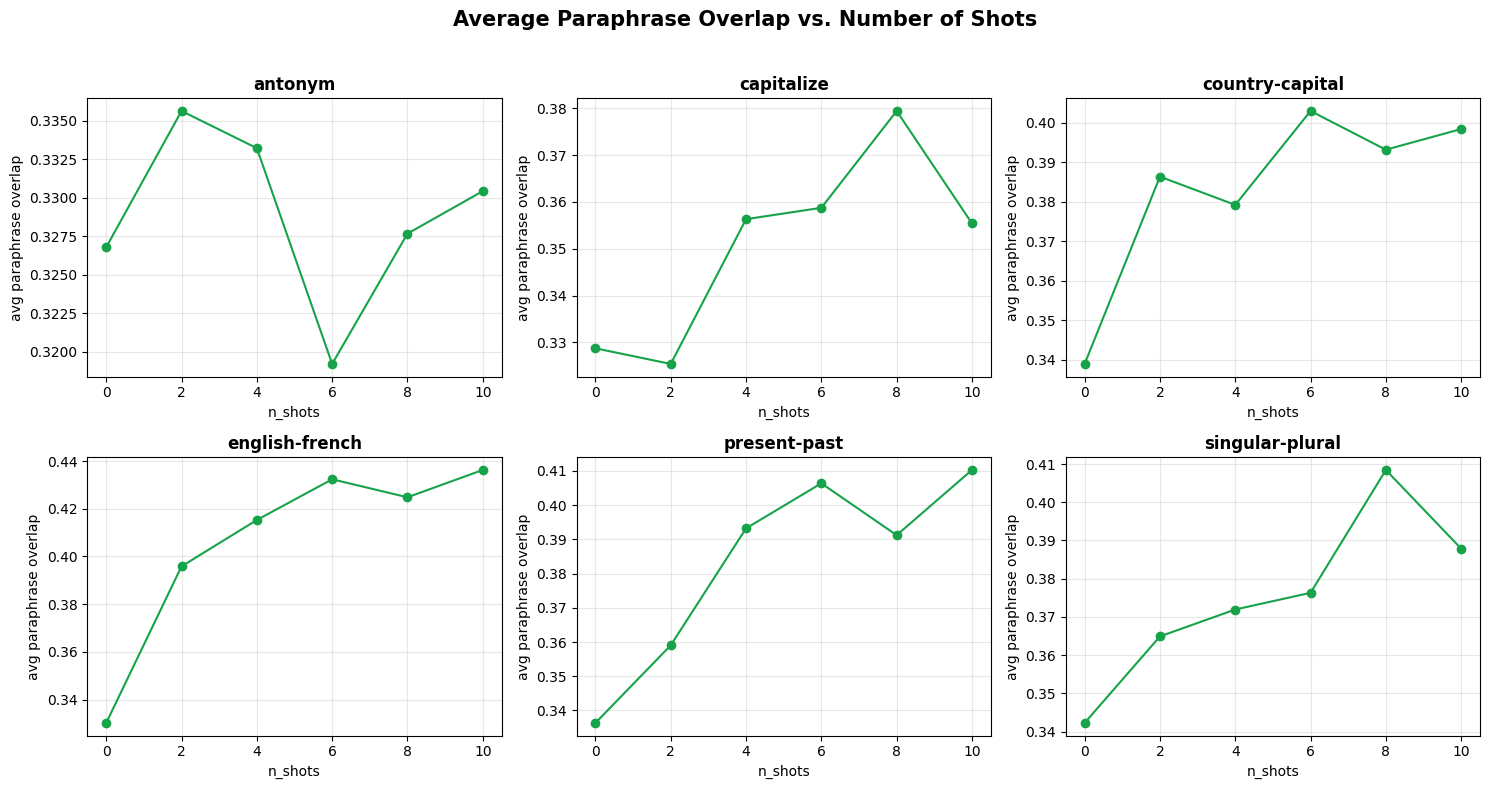

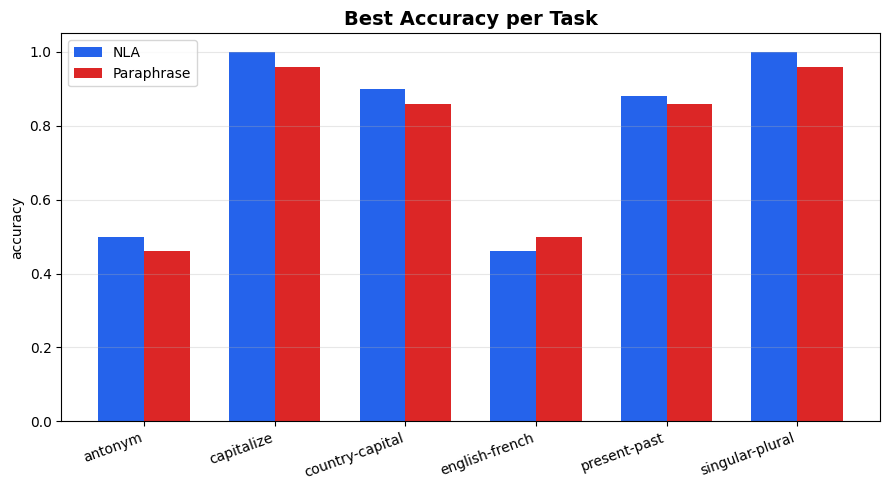

In [2]:
"""
Visualize function-vector shot-sweep results (NLA vs paraphrase steering).

Expects CSVs named like: fv_shot_sweep_<task>_<timestamp>.csv
with columns: n_shots, n, acc_nla, acc_para, fve_nla, fve_para,
avg_para_overlap, para_low_overlap_count

Usage:
    python plot_fv_shot_sweep.py /path/to/csv/dir  [--out out_dir]
"""
import glob
import os
import re

import matplotlib.pyplot as plt
import pandas as pd

TASK_RE = re.compile(r"fv_shot_sweep_(.+?)_\d{8}_\d{6}\.csv$")


def load_sweeps(csv_dir):
    """Load every fv_shot_sweep_*.csv in csv_dir into {task_name: DataFrame}."""
    sweeps = {}
    for path in sorted(glob.glob(os.path.join(csv_dir, "fv_shot_sweep_*.csv"))):
        m = TASK_RE.search(os.path.basename(path))
        task = m.group(1) if m else os.path.basename(path)
        df = pd.read_csv(path).sort_values("n_shots")
        sweeps[task] = df
    return sweeps


def plot_accuracy_grid(sweeps, out_path):
    """Grid of accuracy (NLA vs paraphrase) vs n_shots, one subplot per task."""
    n = len(sweeps)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)

    for ax, (task, df) in zip(axes.flat, sweeps.items()):
        ax.plot(df["n_shots"], df["acc_nla"], marker="o", label="NLA", color="#2563eb")
        ax.plot(df["n_shots"], df["acc_para"], marker="s", label="Paraphrase", color="#dc2626")
        ax.set_title(task, fontsize=12, fontweight="bold")
        ax.set_xlabel("n_shots")
        ax.set_ylabel("accuracy")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    # hide unused axes
    for ax in axes.flat[len(sweeps):]:
        ax.axis("off")

    fig.suptitle("fraction of variance explained vs. Number of Shots", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_path, dpi=150)


def plot_fve_grid(sweeps, out_path):
    """Grid of function-vector-effect (fve) vs n_shots, one subplot per task."""
    n = len(sweeps)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)

    for ax, (task, df) in zip(axes.flat, sweeps.items()):
        ax.plot(df["n_shots"], df["fve_nla"], marker="o", label="NLA", color="#2563eb")
        ax.plot(df["n_shots"], df["fve_para"], marker="s", label="Paraphrase", color="#dc2626")
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
        ax.set_title(task, fontsize=12, fontweight="bold")
        ax.set_xlabel("n_shots")
        ax.set_ylabel("fraction of variance explained")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    for ax in axes.flat[len(sweeps):]:
        ax.axis("off")

    fig.suptitle("fraction of variance explained vs. Number of Shots", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_path, dpi=150)


def plot_overlap_grid(sweeps, out_path):
    """Grid of avg_para_overlap vs n_shots, one subplot per task."""
    n = len(sweeps)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)

    for ax, (task, df) in zip(axes.flat, sweeps.items()):
        ax.plot(df["n_shots"], df["avg_para_overlap"], marker="o", color="#16a34a")
        ax.set_title(task, fontsize=12, fontweight="bold")
        ax.set_xlabel("n_shots")
        ax.set_ylabel("avg paraphrase overlap")
        ax.grid(alpha=0.3)

    for ax in axes.flat[len(sweeps):]:
        ax.axis("off")

    fig.suptitle("Average Paraphrase Overlap vs. Number of Shots", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_path, dpi=150)


def plot_summary_bar(sweeps, out_path, n_shots_focus=None):
    """Bar chart comparing best (or a fixed n_shots) NLA vs paraphrase accuracy per task."""
    tasks, nla_vals, para_vals = [], [], []
    for task, df in sweeps.items():
        if n_shots_focus is not None and n_shots_focus in df["n_shots"].values:
            row = df[df["n_shots"] == n_shots_focus].iloc[0]
            nla_vals.append(row["acc_nla"])
            para_vals.append(row["acc_para"])
        else:
            nla_vals.append(df["acc_nla"].max())
            para_vals.append(df["acc_para"].max())
        tasks.append(task)

    x = range(len(tasks))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar([i - width / 2 for i in x], nla_vals, width, label="NLA", color="#2563eb")
    ax.bar([i + width / 2 for i in x], para_vals, width, label="Paraphrase", color="#dc2626")
    ax.set_xticks(list(x))
    ax.set_xticklabels(tasks, rotation=20, ha="right")
    ax.set_ylabel("accuracy")
    title = (
        f"Accuracy at n_shots={n_shots_focus}" if n_shots_focus is not None else "Best Accuracy per Task"
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)


def main(csv_dir, out_dir="fv_sweep_plots"):
    os.makedirs(out_dir, exist_ok=True)
    sweeps = load_sweeps(csv_dir)
    if not sweeps:
        raise ValueError(f"No fv_shot_sweep_*.csv files found in {csv_dir}")

    plot_accuracy_grid(sweeps, os.path.join(out_dir, "accuracy_by_shots.png"))
    plot_fve_grid(sweeps, os.path.join(out_dir, "fve_by_shots.png"))
    plot_overlap_grid(sweeps, os.path.join(out_dir, "overlap_by_shots.png"))
    plot_summary_bar(sweeps, os.path.join(out_dir, "best_accuracy_summary.png"))

    print(f"Saved plots to {out_dir}/")
    return sweeps


# Fill in your CSV directory below and run.
csv_dir = "/mnt/ssd-2/soar-nla/kaylee"
out_dir = "/mnt/ssd-2/soar-nla/kaylee/fv_sweep_plots"
os.makedirs(out_dir, exist_ok=True)

sweeps = main(csv_dir, out_dir)